# Kepler Objects of Interest — Tabular EDA & Classification

**CO5177 · Programming Foundation for Data Analytics and Visualization**  
**Student:** Dinh Hoang Duy Khanh · **ID:** 2670306 · **Group:** Trailblazer

This notebook studies the NASA Kepler Objects of Interest (KOI) cumulative
catalogue. A KOI is a transit-like signal that may be a confirmed planet, a
planet candidate, or a false positive. The analysis asks:

1. Is the catalogue suitable for the CO5177 tabular-data requirements?
2. Which data-quality issues and physical measurements matter most?
3. Can a leakage-safe model distinguish the three catalogue dispositions?
4. Does a nonlinear, class-aware model improve on a linear baseline?

Every chart is produced in its own cell and figure. This makes each result
easy to inspect, rerun, and reuse in the project website.

## 0. Reproducibility and data source

The data come directly from the
[NASA Exoplanet Archive TAP service](https://exoplanetarchive.ipac.caltech.edu/).
The selected table contains more than 2,000 rows, more than 10 columns,
missing values, categorical fields, numerical fields, class imbalance, and
outliers—meeting the assignment's tabular constraints.

The Kaggle notebook *Kepler Objects of Interest — Exploratory Analysis* was
used as a reference for domain-aware feature selection. This implementation
is rewritten for the CO5177 rubric and intentionally excludes columns that
would leak the final disposition into the model.

In [1]:
from pathlib import Path
from urllib.parse import urlencode

import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    f1_score,
)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
RANDOM_STATE = 42
PALETTE = ["#d35b12", "#efae00", "#173f4c"]
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 180})

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"
DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


def finish_plot(filename: str) -> None:
    """Save the current figure, render it, and release its memory."""
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / filename, bbox_inches="tight", facecolor="white")
    plt.show()
    plt.close()

### Download a reproducible subset of the cumulative KOI table

The query keeps identifiers, labels, diagnostic flags, uncertainties, and
physical measurements. The local CSV is a cache: delete it to fetch a fresh
catalogue from NASA.

In [2]:
SELECTED_COLUMNS = [
    "kepid", "kepoi_name", "kepler_name", "koi_disposition",
    "koi_pdisposition", "koi_score", "koi_fpflag_nt", "koi_fpflag_ss",
    "koi_fpflag_co", "koi_fpflag_ec", "koi_period", "koi_period_err1",
    "koi_period_err2", "koi_impact", "koi_duration", "koi_depth",
    "koi_prad", "koi_prad_err1", "koi_prad_err2", "koi_teq",
    "koi_insol", "koi_model_snr", "koi_tce_plnt_num",
    "koi_tce_delivname", "koi_steff", "koi_slogg", "koi_srad",
    "ra", "dec", "koi_kepmag",
]

query = f"select {','.join(SELECTED_COLUMNS)} from cumulative"
DATA_URL = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync?" + urlencode(
    {"query": query, "format": "csv"}
)
DATA_PATH = DATA_DIR / "koi_cumulative.csv"

if DATA_PATH.exists():
    df = pd.read_csv(DATA_PATH)
    print(f"Loaded cached data: {DATA_PATH}")
else:
    df = pd.read_csv(DATA_URL)
    df.to_csv(DATA_PATH, index=False)
    print(f"Downloaded and cached data: {DATA_PATH}")

df_raw = df.copy()
display(df.head())

Loaded cached data: E:\Scientific Research\JOURNAL 2026\ECHO-KINN\site-preview\data\koi_cumulative.csv


,kepid,kepoi_name,kepler_name,koi_disposition,koi_pdisposition,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,koi_fpflag_ec,...,koi_insol,koi_model_snr,koi_tce_plnt_num,koi_tce_delivname,koi_steff,koi_slogg,koi_srad,ra,dec,koi_kepmag
0,10797460,K00752.01,Kepler-227 b,CONFIRMED,CANDIDATE,1.000,0,0,0,0,...,93.59,35.8,1.0,q1_q17_dr25_tce,5455.0,4.467,0.927,291.93423,48.141651,15.347
1,10797460,K00752.02,Kepler-227 c,CONFIRMED,CANDIDATE,0.969,0,0,0,0,...,9.11,25.8,2.0,q1_q17_dr25_tce,5455.0,4.467,0.927,291.93423,48.141651,15.347
2,10811496,K00753.01,NaN,CANDIDATE,CANDIDATE,0.000,0,0,0,0,...,39.30,76.3,1.0,q1_q17_dr25_tce,5853.0,4.544,0.868,297.00482,48.134129,15.436
3,10848459,K00754.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,0,...,891.96,505.6,1.0,q1_q17_dr25_tce,5805.0,4.564,0.791,285.53461,48.285210,15.597
4,10854555,K00755.01,Kepler-664 b,CONFIRMED,CANDIDATE,1.000,0,0,0,0,...,926.16,40.9,1.0,q1_q17_dr25_tce,6031.0,4.438,1.046,288.75488,48.226200,15.509


In [3]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"Duplicate rows: {df.duplicated().sum():,}")
print(f"Numerical columns: {df.select_dtypes(include='number').shape[1]}")
print(f"Categorical columns: {df.select_dtypes(exclude='number').shape[1]}")

Rows: 9,564
Columns: 30
Duplicate rows: 0
Numerical columns: 25
Categorical columns: 5


**Check:** the catalogue comfortably exceeds 2,000 rows and 10 columns. It
mixes continuous measurements, binary flags, identifiers, and categorical
labels, so it is a valid tabular dataset for the assignment.

## 1. Dataset overview

In [4]:
overview = pd.DataFrame(
    {
        "metric": [
            "Rows", "Columns", "Numerical columns", "Categorical columns",
            "Missing cells", "Target classes",
        ],
        "value": [
            len(df), df.shape[1], df.select_dtypes(include="number").shape[1],
            df.select_dtypes(exclude="number").shape[1],
            int(df.isna().sum().sum()), df["koi_disposition"].nunique(),
        ],
    }
)
display(overview)

,metric,value
0,Rows,9564
1,Columns,30
2,Numerical columns,25
3,Categorical columns,5
4,Missing cells,13878
5,Target classes,3


## 2. Target distribution

,count,percentage
koi_disposition,,
FALSE POSITIVE,4839,50.60
CONFIRMED,2748,28.73
CANDIDATE,1977,20.67


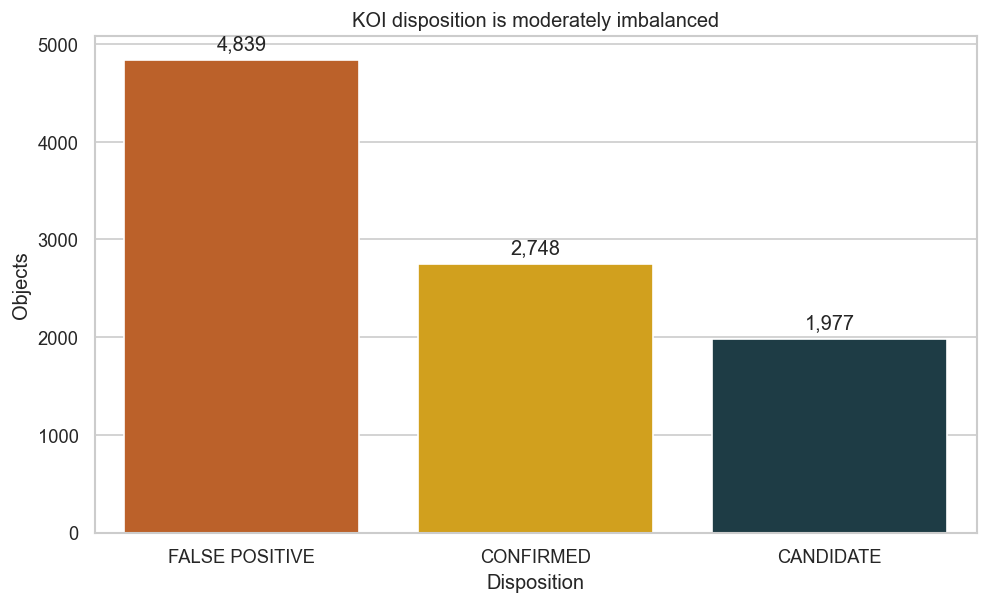

In [5]:
target_counts = df["koi_disposition"].value_counts()
target_share = df["koi_disposition"].value_counts(normalize=True).mul(100)
target_summary = pd.concat(
    [target_counts.rename("count"), target_share.rename("percentage")], axis=1
).round(2)
display(target_summary)

plt.figure(figsize=(8.4, 5.2))
ax = sns.barplot(
    x=target_summary.index,
    y=target_summary["count"],
    hue=target_summary.index,
    palette=PALETTE,
    legend=False,
)
ax.set(title="KOI disposition is moderately imbalanced", xlabel="Disposition", ylabel="Objects")
for container in ax.containers:
    ax.bar_label(container, fmt="{:,.0f}", padding=4)
finish_plot("01_target_distribution.png")

**Finding:** false positives form the largest class. Accuracy alone is not
sufficient, so model comparison will also use macro F1 and balanced accuracy.

## 3. Missing values

,missing_count,missing_pct
kepler_name,6816,71.27
koi_score,1510,15.79
koi_period_err1,454,4.75
koi_period_err2,454,4.75
koi_impact,363,3.80
koi_depth,363,3.80
koi_prad,363,3.80
koi_prad_err1,363,3.80
koi_prad_err2,363,3.80
koi_teq,363,3.80


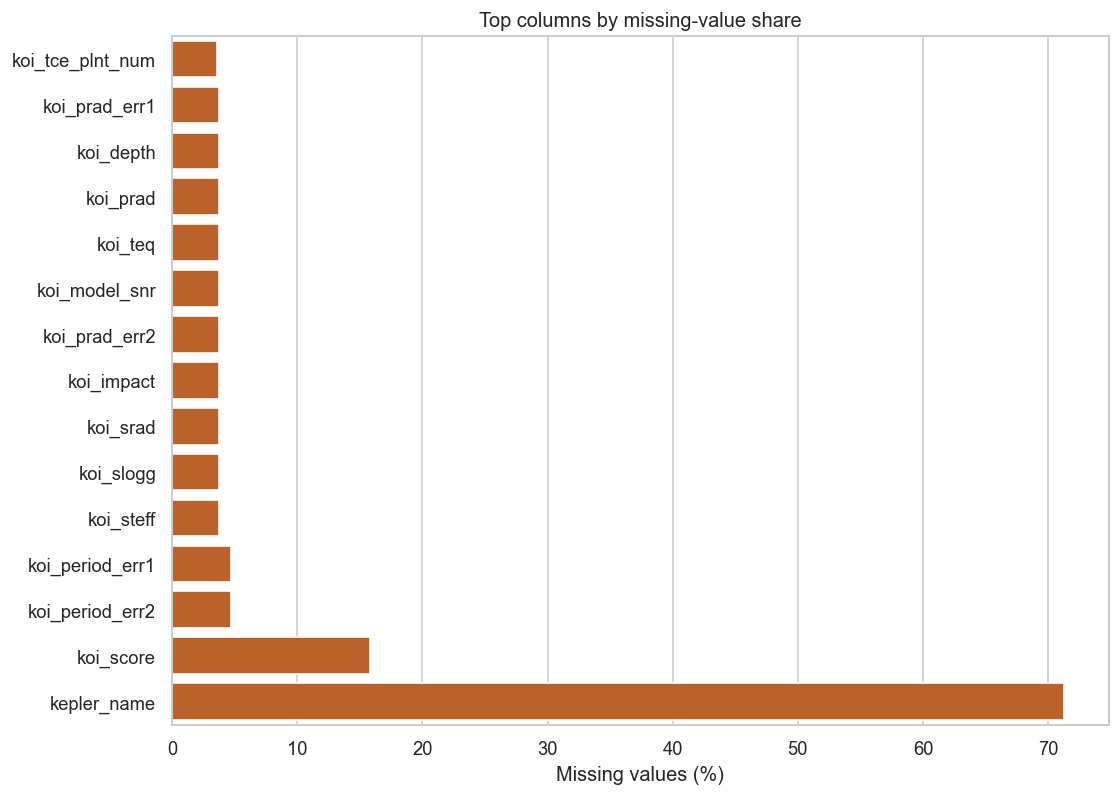

In [6]:
missing_summary = (
    df.isna().sum().rename("missing_count").to_frame()
    .assign(missing_pct=lambda table: table["missing_count"] / len(df) * 100)
    .query("missing_count > 0")
    .sort_values("missing_pct", ascending=False)
)
display(missing_summary.round(2))

plt.figure(figsize=(9.5, 6.8))
missing_plot = missing_summary.head(15).sort_values("missing_pct")
ax = sns.barplot(
    data=missing_plot,
    x="missing_pct",
    y=missing_plot.index,
    color="#d35b12",
)
ax.set(title="Top columns by missing-value share", xlabel="Missing values (%)", ylabel="")
finish_plot("02_missing_values.png")

**Finding:** missingness is concentrated in a limited set of physical
measurements. The models therefore use median imputation for numerical
features and most-frequent imputation for categorical features.

## 4. Important numerical distributions

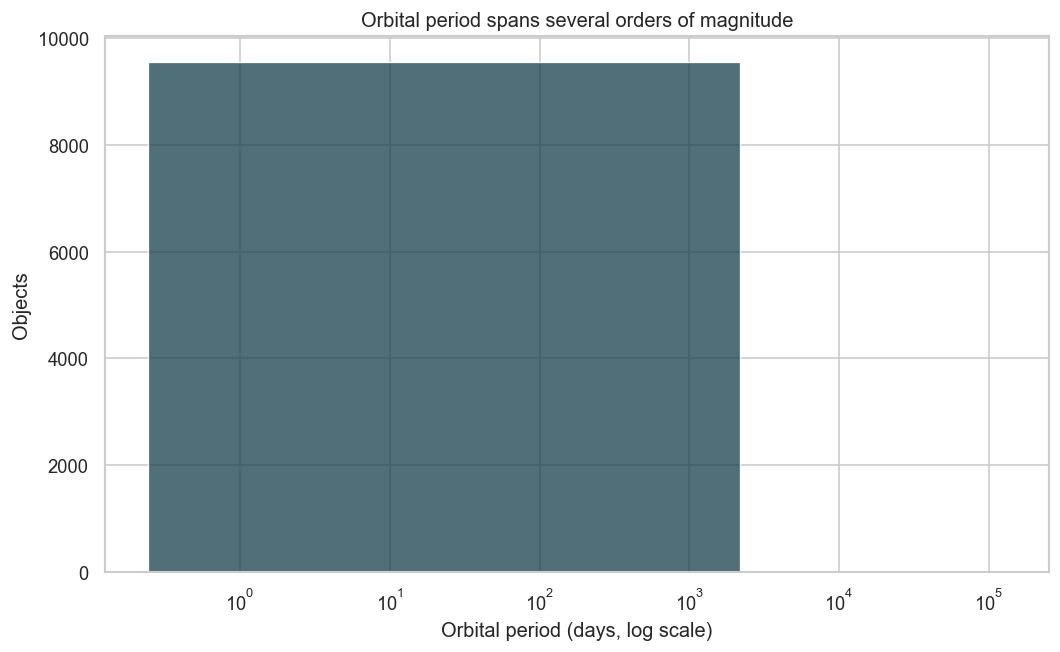

In [7]:
plt.figure(figsize=(9, 5.6))
ax = sns.histplot(df["koi_period"].dropna(), bins=60, color="#173f4c")
ax.set_xscale("log")
ax.set(title="Orbital period spans several orders of magnitude", xlabel="Orbital period (days, log scale)", ylabel="Objects")
finish_plot("03_orbital_period_distribution.png")

**Finding:** orbital period is strongly right-skewed. The log axis preserves
the common short-period objects while keeping long-period objects visible.

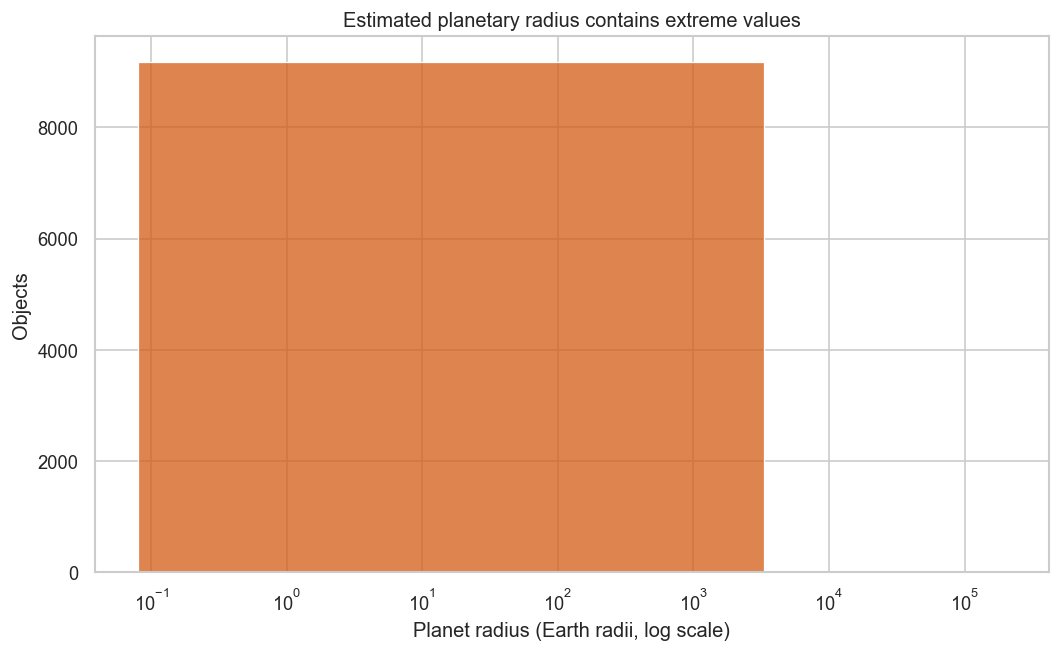

In [8]:
plt.figure(figsize=(9, 5.6))
radius = df.loc[df["koi_prad"].gt(0), "koi_prad"].dropna()
ax = sns.histplot(radius, bins=60, color="#d35b12")
ax.set_xscale("log")
ax.set(title="Estimated planetary radius contains extreme values", xlabel="Planet radius (Earth radii, log scale)", ylabel="Objects")
finish_plot("04_planet_radius_distribution.png")

**Finding:** the radius distribution has a long tail. Robust preprocessing
and a nonlinear model are reasonable candidates for comparison.

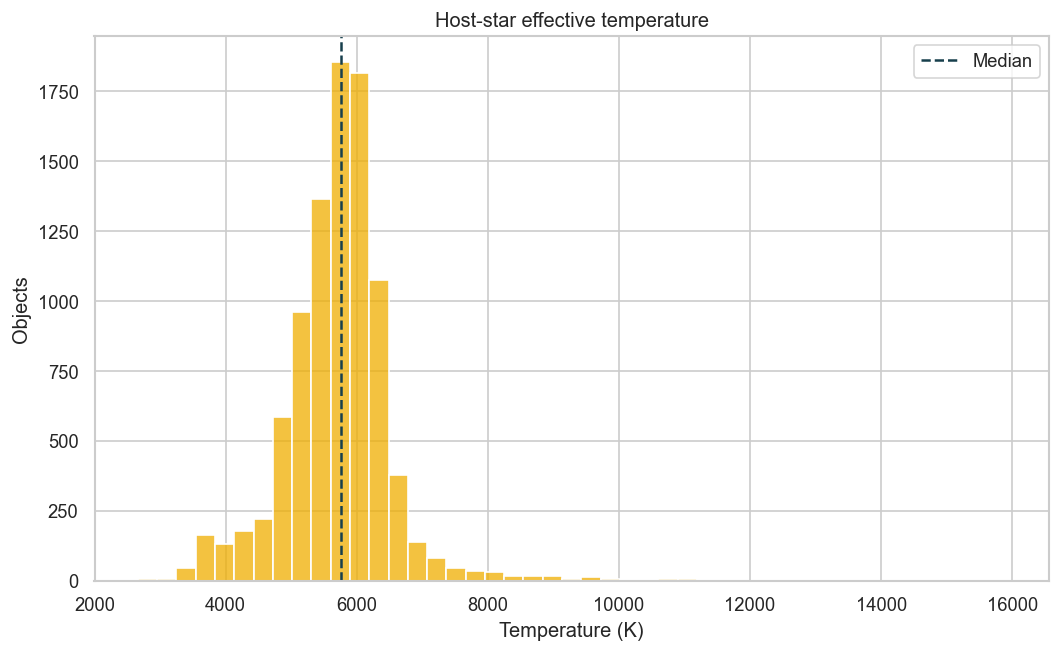

In [9]:
plt.figure(figsize=(9, 5.6))
ax = sns.histplot(df["koi_steff"].dropna(), bins=45, color="#efae00")
ax.axvline(df["koi_steff"].median(), color="#173f4c", linestyle="--", label="Median")
ax.set(title="Host-star effective temperature", xlabel="Temperature (K)", ylabel="Objects")
ax.legend()
finish_plot("05_stellar_temperature_distribution.png")

**Finding:** most KOIs orbit stars in a relatively dense temperature band,
with a smaller number of unusually cool or hot hosts.

## 5. Categorical feature distribution

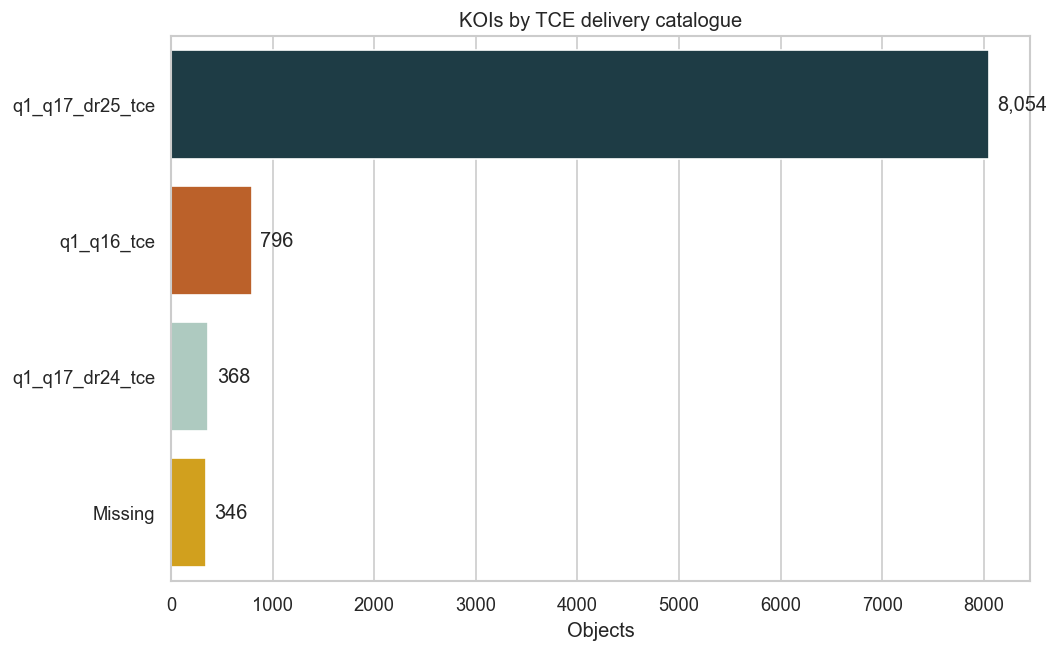

In [10]:
delivery_counts = (
    df["koi_tce_delivname"]
    .fillna("Missing")
    .value_counts()
    .rename_axis("delivery_catalogue")
    .reset_index(name="objects")
)

plt.figure(figsize=(9, 5.6))
ax = sns.barplot(
    data=delivery_counts,
    x="objects",
    y="delivery_catalogue",
    hue="delivery_catalogue",
    palette=["#173f4c", "#d35b12", "#a9cfc1", "#efae00"],
    legend=False,
)
ax.set(title="KOIs by TCE delivery catalogue", xlabel="Objects", ylabel="")
for container in ax.containers:
    ax.bar_label(container, padding=5, fmt="{:,.0f}")
finish_plot("15_tce_delivery_distribution.png")

**Finding:** the DR25 catalogue supplies most records. Delivery name is kept
as a categorical model input and missing values are handled inside the fitted
preprocessing pipeline.

## 6. Outlier audit

,feature,outliers,outlier_pct
3,koi_depth,1798,19.54
7,koi_model_snr,1600,17.39
0,koi_period,1567,16.38
4,koi_prad,1469,15.97
6,koi_insol,1438,15.56
10,koi_srad,985,10.71
2,koi_duration,869,9.09
9,koi_slogg,663,7.21
8,koi_steff,552,6.00
5,koi_teq,411,4.47


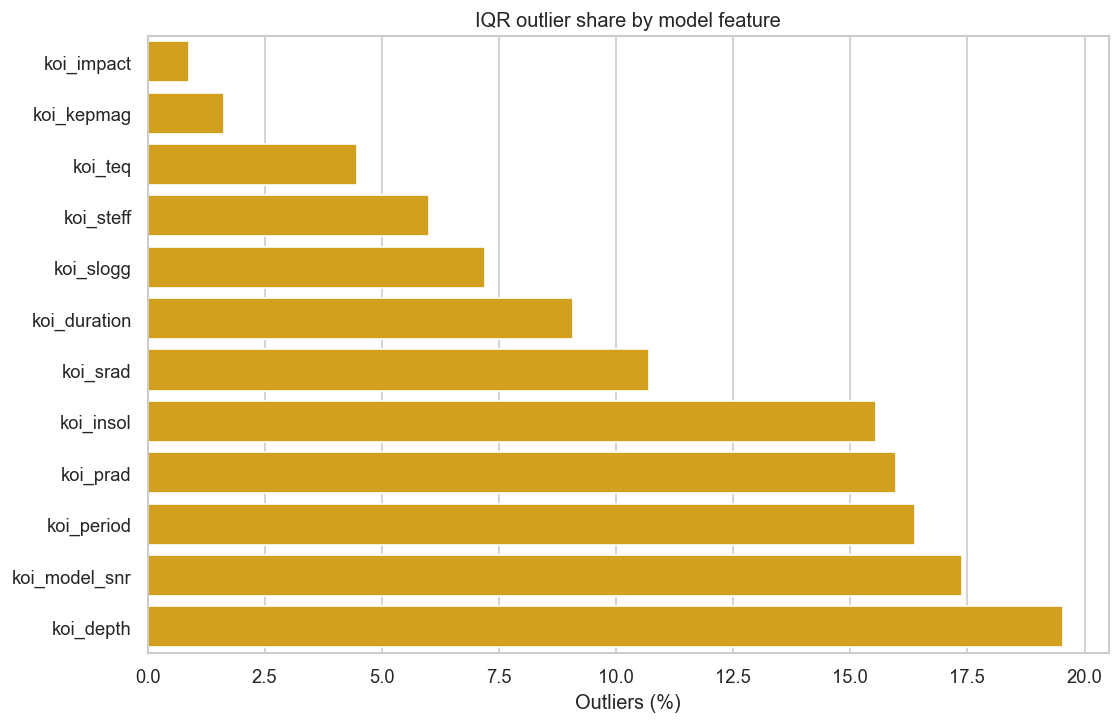

In [11]:
MODEL_NUMERIC_FEATURES = [
    "koi_period", "koi_impact", "koi_duration", "koi_depth", "koi_prad",
    "koi_teq", "koi_insol", "koi_model_snr", "koi_steff", "koi_slogg",
    "koi_srad", "koi_kepmag",
]

outlier_rows = []
for column in MODEL_NUMERIC_FEATURES:
    values = df[column].dropna()
    q1, q3 = values.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outlier_count = int(((values < lower) | (values > upper)).sum())
    outlier_rows.append(
        {"feature": column, "outliers": outlier_count, "outlier_pct": outlier_count / len(values) * 100}
    )

outlier_summary = pd.DataFrame(outlier_rows).sort_values("outlier_pct", ascending=False)
display(outlier_summary.round(2))

plt.figure(figsize=(9.5, 6.2))
outlier_plot = outlier_summary.sort_values("outlier_pct")
ax = sns.barplot(data=outlier_plot, x="outlier_pct", y="feature", color="#efae00")
ax.set(title="IQR outlier share by model feature", xlabel="Outliers (%)", ylabel="")
finish_plot("06_outlier_share.png")

**Finding:** the catalogue genuinely contains many IQR outliers. They are not
deleted blindly because unusual astronomical objects may be scientifically
meaningful; the baseline uses scaling, while the extended tree model handles
nonlinear ranges without assuming a Gaussian distribution.

## 7. Target–feature relationships

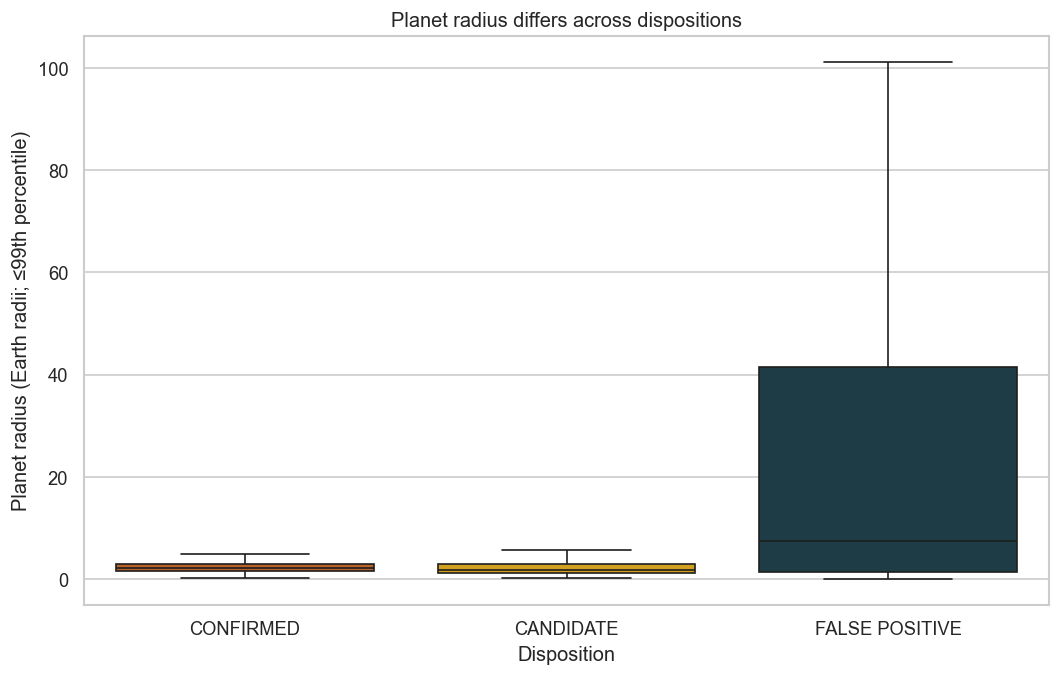

In [12]:
plot_data = df.loc[df["koi_prad"].between(0, df["koi_prad"].quantile(0.99))]
plt.figure(figsize=(9, 5.8))
ax = sns.boxplot(
    data=plot_data,
    x="koi_disposition",
    y="koi_prad",
    hue="koi_disposition",
    palette=PALETTE,
    legend=False,
    showfliers=False,
)
ax.set(title="Planet radius differs across dispositions", xlabel="Disposition", ylabel="Planet radius (Earth radii; ≤99th percentile)")
finish_plot("07_target_vs_planet_radius.png")

**Finding:** false positives tend to occupy a broader and larger radius range,
but the class distributions overlap—one variable cannot solve the task alone.

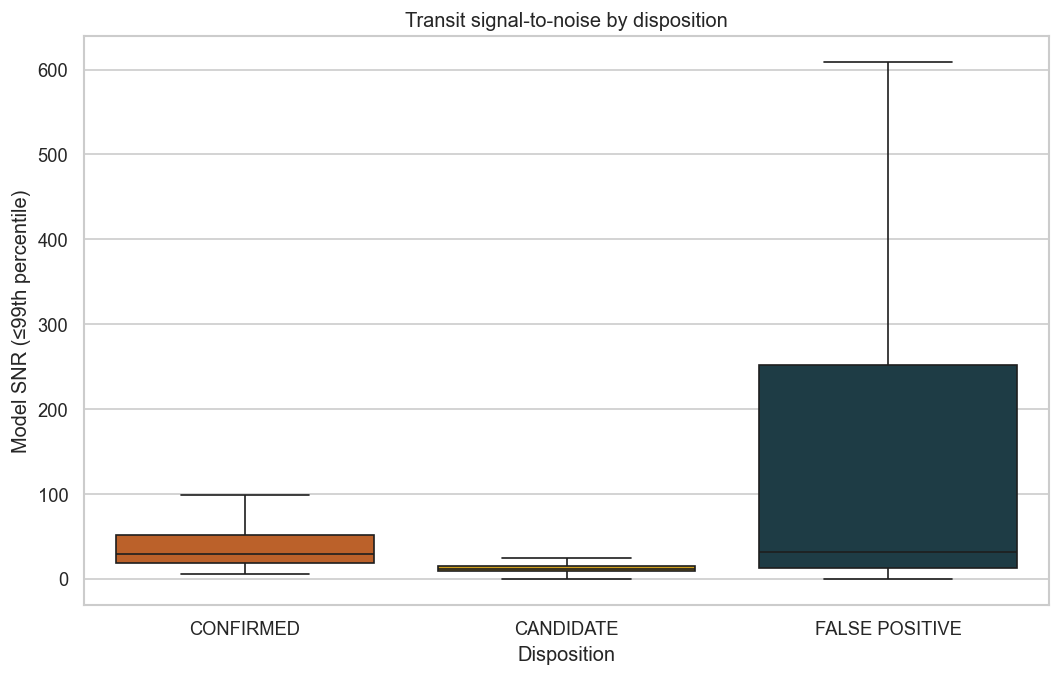

In [13]:
plot_data = df.loc[df["koi_model_snr"].between(0, df["koi_model_snr"].quantile(0.99))]
plt.figure(figsize=(9, 5.8))
ax = sns.boxplot(
    data=plot_data,
    x="koi_disposition",
    y="koi_model_snr",
    hue="koi_disposition",
    palette=PALETTE,
    legend=False,
    showfliers=False,
)
ax.set(title="Transit signal-to-noise by disposition", xlabel="Disposition", ylabel="Model SNR (≤99th percentile)")
finish_plot("08_target_vs_snr.png")

**Finding:** signal strength also separates some objects but retains substantial
overlap. A multivariate model is needed.

## 8. Correlation structure

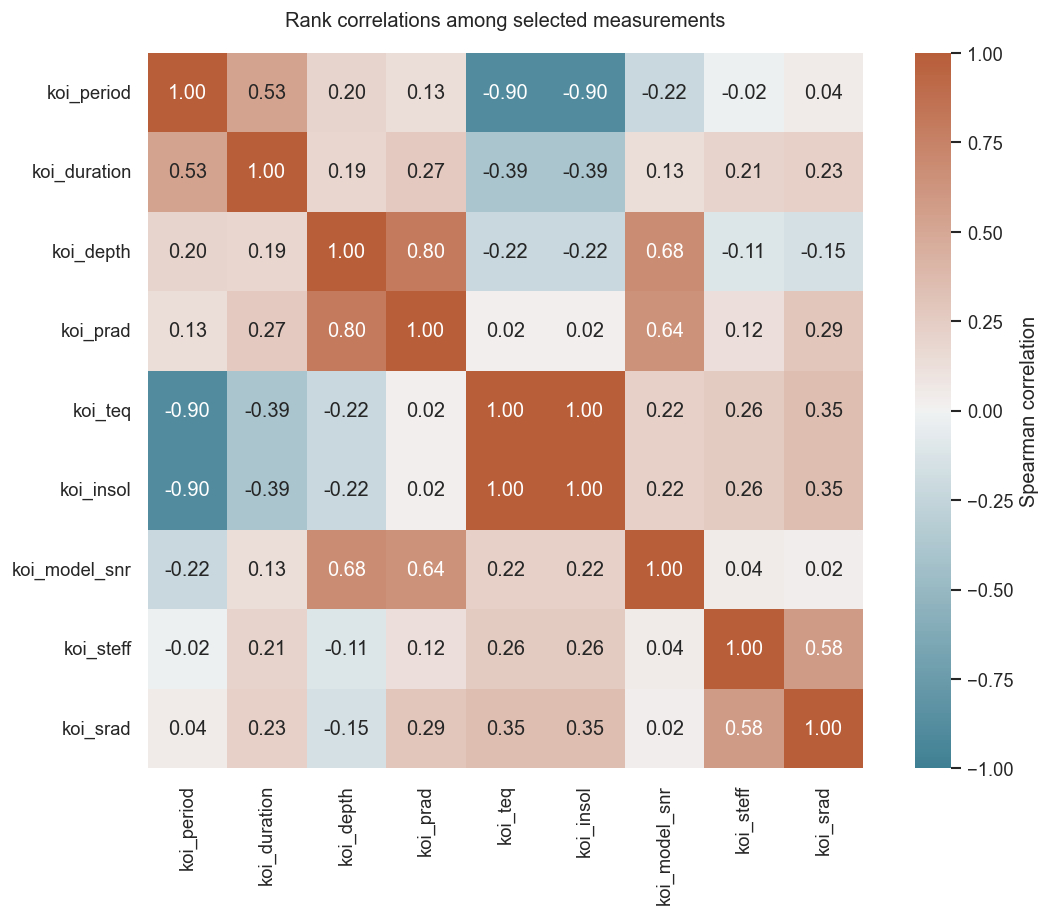

In [14]:
correlation_features = [
    "koi_period", "koi_duration", "koi_depth", "koi_prad",
    "koi_teq", "koi_insol", "koi_model_snr", "koi_steff", "koi_srad",
]
correlation = df[correlation_features].corr(method="spearman")

plt.figure(figsize=(10, 7.8))
ax = sns.heatmap(
    correlation,
    cmap=sns.diverging_palette(220, 25, as_cmap=True),
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    square=True,
    cbar_kws={"label": "Spearman correlation"},
)
ax.set_title("Rank correlations among selected measurements", pad=16)
finish_plot("09_correlation_heatmap.png")

**Finding:** some physical variables are related, but no single compact block
explains the target. This supports testing interactions through a tree ensemble.

## 9. Leakage-safe data preparation

The following fields are deliberately **excluded** from the input features:

- `koi_pdisposition`, `koi_score`, and the four false-positive flags because
  they are produced by the vetting pipeline and strongly encode the outcome;
- `kepler_name` because confirmed objects receive a Kepler name;
- object identifiers because they have no transferable physical meaning.

`koi_tce_delivname` is retained as the categorical feature for one-hot
encoding. Numerical values are median-imputed and scaled. Splits are grouped
by `kepid`, so observations from the same host star cannot appear in both the
training and evaluation sets.

In [15]:
CATEGORICAL_FEATURES = ["koi_tce_delivname"]
TARGET = "koi_disposition"
FEATURES = MODEL_NUMERIC_FEATURES + CATEGORICAL_FEATURES

model_df = df.dropna(subset=[TARGET, "kepid"]).copy()
X = model_df[FEATURES]
y = model_df[TARGET]
groups = model_df["kepid"]

outer_split = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=RANDOM_STATE)
train_idx, holdout_idx = next(outer_split.split(X, y, groups))
X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
holdout = model_df.iloc[holdout_idx]

inner_split = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=RANDOM_STATE)
val_rel_idx, test_rel_idx = next(
    inner_split.split(holdout[FEATURES], holdout[TARGET], holdout["kepid"])
)
X_val = holdout.iloc[val_rel_idx][FEATURES]
y_val = holdout.iloc[val_rel_idx][TARGET]
X_test = holdout.iloc[test_rel_idx][FEATURES]
y_test = holdout.iloc[test_rel_idx][TARGET]

split_summary = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "rows": [len(X_train), len(X_val), len(X_test)],
        "host_stars": [
            model_df.iloc[train_idx]["kepid"].nunique(),
            holdout.iloc[val_rel_idx]["kepid"].nunique(),
            holdout.iloc[test_rel_idx]["kepid"].nunique(),
        ],
    }
)
display(split_summary)

train_hosts = set(model_df.iloc[train_idx]["kepid"])
val_hosts = set(holdout.iloc[val_rel_idx]["kepid"])
test_hosts = set(holdout.iloc[test_rel_idx]["kepid"])
assert train_hosts.isdisjoint(val_hosts)
assert train_hosts.isdisjoint(test_hosts)
assert val_hosts.isdisjoint(test_hosts)

,split,rows,host_stars
0,train,6695,5749
1,validation,1463,1232
2,test,1406,1233


## 10. Before and after scaling

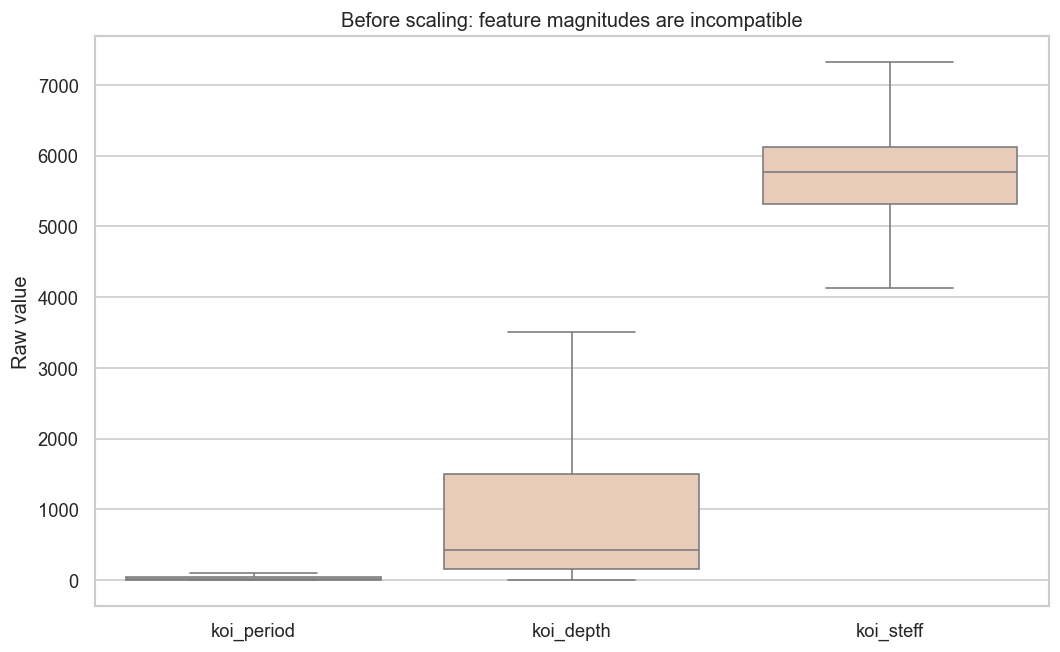

In [16]:
raw_scaling_frame = X_train[["koi_period", "koi_depth", "koi_steff"]].copy()
raw_scaling_long = raw_scaling_frame.melt(var_name="feature", value_name="value").dropna()
plt.figure(figsize=(9, 5.6))
ax = sns.boxplot(data=raw_scaling_long, x="feature", y="value", color="#f1c9b2", showfliers=False)
ax.set(title="Before scaling: feature magnitudes are incompatible", xlabel="", ylabel="Raw value")
finish_plot("10_before_scaling.png")

**Finding:** temperature and transit depth dominate the raw numeric scale;
distance-based optimization would treat the variables unevenly.

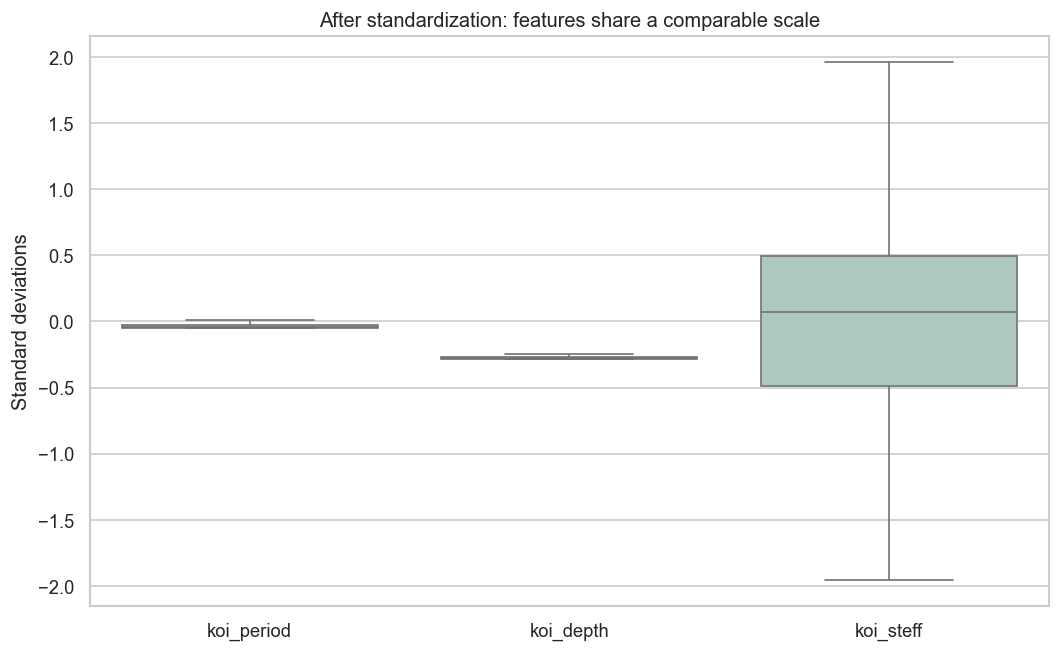

In [17]:
scaling_sample = X_train[["koi_period", "koi_depth", "koi_steff"]].copy()
scaling_sample = scaling_sample.fillna(scaling_sample.median())
scaled_values = StandardScaler().fit_transform(scaling_sample)
scaled_frame = pd.DataFrame(scaled_values, columns=scaling_sample.columns)
scaled_long = scaled_frame.melt(var_name="feature", value_name="standardized value")

plt.figure(figsize=(9, 5.6))
ax = sns.boxplot(data=scaled_long, x="feature", y="standardized value", color="#a9cfc1", showfliers=False)
ax.set(title="After standardization: features share a comparable scale", xlabel="", ylabel="Standard deviations")
finish_plot("11_after_scaling.png")

**Finding:** standardization centers each feature near zero with comparable
units. This transformation is fitted only on training data inside the model
pipeline to prevent evaluation leakage.

## 11. Baseline vs extended model

In [18]:
baseline_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            MODEL_NUMERIC_FEATURES,
        ),
        (
            "categorical",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("encoder", OneHotEncoder(handle_unknown="ignore")),
                ]
            ),
            CATEGORICAL_FEATURES,
        ),
    ]
)

extended_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", RobustScaler()),
                ]
            ),
            MODEL_NUMERIC_FEATURES,
        ),
        (
            "categorical",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("encoder", OneHotEncoder(handle_unknown="ignore")),
                ]
            ),
            CATEGORICAL_FEATURES,
        ),
    ]
)

models = {
    "Logistic baseline": Pipeline(
        steps=[
            ("preprocessor", baseline_preprocessor),
            ("classifier", LogisticRegression(max_iter=2500, random_state=RANDOM_STATE)),
        ]
    ),
    "Balanced Random Forest": Pipeline(
        steps=[
            ("preprocessor", extended_preprocessor),
            (
                "classifier",
                RandomForestClassifier(
                    n_estimators=350,
                    min_samples_leaf=2,
                    class_weight="balanced_subsample",
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ]
    ),
}

validation_rows = []
for name, model in models.items():
    model.fit(X_train, y_train)
    prediction = model.predict(X_val)
    validation_rows.append(
        {
            "model": name,
            "accuracy": accuracy_score(y_val, prediction),
            "balanced_accuracy": balanced_accuracy_score(y_val, prediction),
            "macro_f1": f1_score(y_val, prediction, average="macro"),
        }
    )

validation_results = pd.DataFrame(validation_rows).set_index("model").sort_values("macro_f1", ascending=False)
display(validation_results.round(4))

,accuracy,balanced_accuracy,macro_f1
model,,,
Balanced Random Forest,0.7881,0.7594,0.7580
Logistic baseline,0.6596,0.5815,0.5582


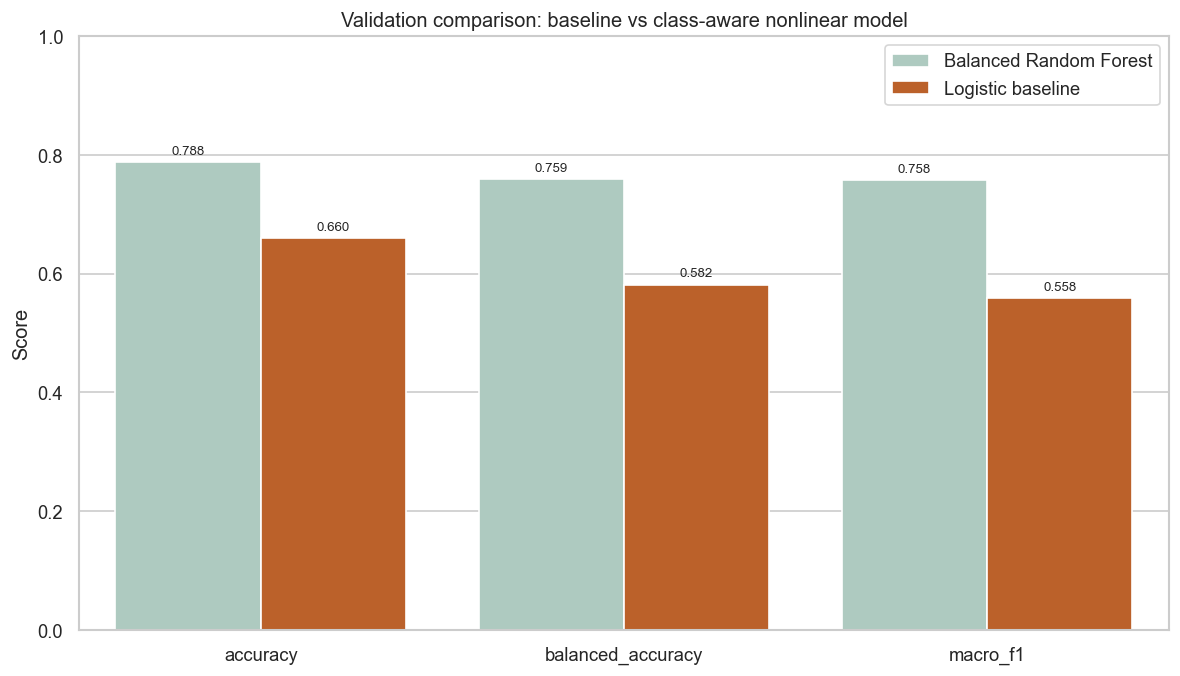

In [19]:
validation_long = (
    validation_results.reset_index()
    .melt(id_vars="model", var_name="metric", value_name="score")
)
plt.figure(figsize=(10, 5.8))
ax = sns.barplot(data=validation_long, x="metric", y="score", hue="model", palette=["#a9cfc1", "#d35b12"])
ax.set(title="Validation comparison: baseline vs class-aware nonlinear model", xlabel="", ylabel="Score", ylim=(0, 1))
ax.legend(title="")
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=8)
finish_plot("12_model_comparison.png")

**Finding:** the comparison uses the untouched validation split. Macro F1 is
the primary selection metric because it gives each disposition equal weight.

## 12. Final test evaluation

The better validation model is now evaluated once on the held-out test set.

In [20]:
best_model_name = validation_results.index[0]
best_model = models[best_model_name]
test_prediction = best_model.predict(X_test)

test_metrics = {
    "model": best_model_name,
    "accuracy": accuracy_score(y_test, test_prediction),
    "balanced_accuracy": balanced_accuracy_score(y_test, test_prediction),
    "macro_f1": f1_score(y_test, test_prediction, average="macro"),
}
display(pd.Series(test_metrics, name="test_result").to_frame())
display(pd.DataFrame(classification_report(y_test, test_prediction, output_dict=True)).T.round(3))

,test_result
model,Balanced Random Forest
accuracy,0.758179
balanced_accuracy,0.730498
macro_f1,0.727488


,precision,recall,f1-score,support
CANDIDATE,0.563,0.535,0.549,301.000
CONFIRMED,0.801,0.858,0.829,381.000
FALSE POSITIVE,0.812,0.798,0.805,724.000
accuracy,0.758,0.758,0.758,0.758
macro avg,0.725,0.730,0.727,1406.000
weighted avg,0.756,0.758,0.757,1406.000


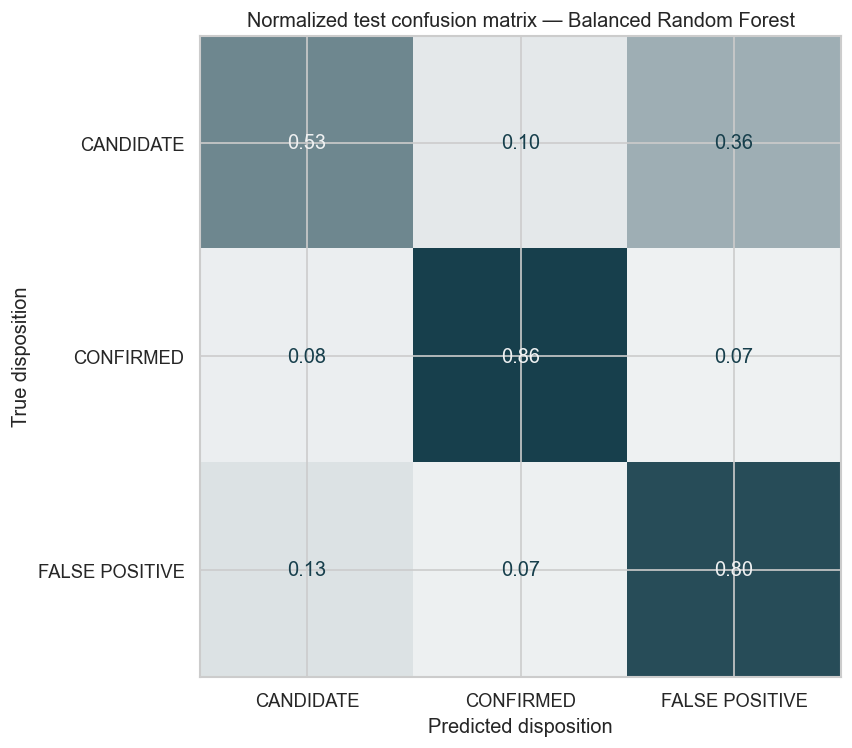

In [21]:
plt.figure(figsize=(7.6, 6.4))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_prediction,
    normalize="true",
    cmap=sns.light_palette("#173f4c", as_cmap=True),
    values_format=".2f",
    ax=plt.gca(),
    colorbar=False,
)
plt.title(f"Normalized test confusion matrix — {best_model_name}")
plt.xlabel("Predicted disposition")
plt.ylabel("True disposition")
finish_plot("13_confusion_matrix.png")

**Finding:** the normalized confusion matrix shows recall separately for each
class and makes minority-class errors visible—something overall accuracy hides.

## 13. Model interpretation

,feature,importance,std
7,koi_model_snr,0.1503,0.0059
4,koi_prad,0.0736,0.0092
1,koi_impact,0.0391,0.0046
12,koi_tce_delivname,0.0347,0.0063
2,koi_duration,0.0327,0.0034
0,koi_period,0.0316,0.0053
3,koi_depth,0.0250,0.0046
6,koi_insol,0.0169,0.0072
5,koi_teq,0.0090,0.0046
10,koi_srad,0.0067,0.0030


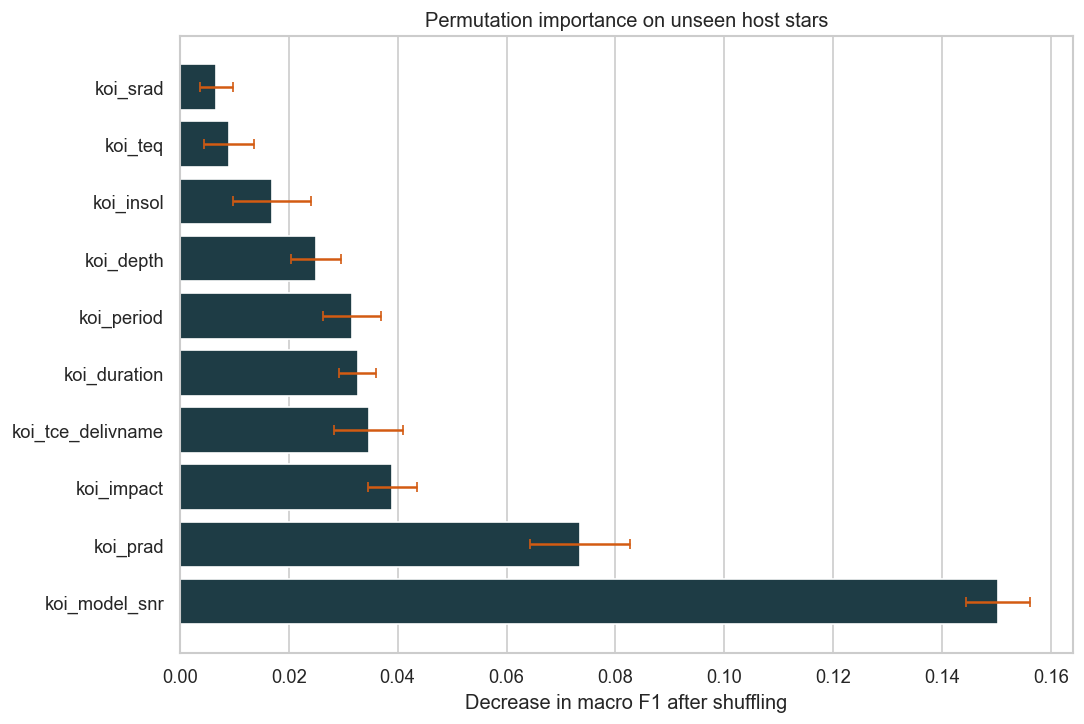

In [22]:
permutation = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=8,
    random_state=RANDOM_STATE,
    scoring="f1_macro",
    n_jobs=-1,
)
importance = (
    pd.DataFrame(
        {
            "feature": FEATURES,
            "importance": permutation.importances_mean,
            "std": permutation.importances_std,
        }
    )
    .sort_values("importance", ascending=False)
)
display(importance.round(4))

plt.figure(figsize=(9.2, 6.2))
importance_plot = importance.head(10).sort_values("importance")
ax = sns.barplot(data=importance_plot, x="importance", y="feature", color="#173f4c")
ax.errorbar(
    importance_plot["importance"],
    np.arange(len(importance_plot)),
    xerr=importance_plot["std"],
    fmt="none",
    ecolor="#d35b12",
    capsize=3,
)
ax.set(title="Permutation importance on unseen host stars", xlabel="Decrease in macro F1 after shuffling", ylabel="")
finish_plot("14_feature_importance.png")

**Finding:** permutation importance measures how much macro F1 drops when one
raw feature is shuffled on unseen host stars. It is more directly tied to
predictive value than an univariate plot, but it still describes this model,
not astronomical causality.

## 14. Conclusions and limitations

### Main conclusions

- The KOI catalogue satisfies all CO5177 tabular constraints and contains real
  missingness, imbalance, skew, and outliers.
- Radius and transit signal strength differ by disposition, but their overlap
  shows why a multivariate classifier is needed.
- Grouping splits by host star provides a more honest evaluation than a random
  row split.
- Comparing macro F1 quantifies whether the extended nonlinear, class-aware
  model improves on the logistic baseline.
- The confusion matrix and permutation importance explain *where* the final
  model succeeds, fails, and obtains signal.

### Limitations

- Catalogue dispositions can change as NASA incorporates new evidence.
- Missing values are imputed, so their uncertainty is not fully propagated.
- The model ranks patterns in catalogue measurements; it does not confirm a
  planet and must not replace physical validation or follow-up observations.
- A later independent catalogue would provide a stronger external test.

In [23]:
summary = {
    "dataset": "NASA Kepler Objects of Interest cumulative table",
    "rows": int(df.shape[0]),
    "columns": int(df.shape[1]),
    "missing_cells": int(df.isna().sum().sum()),
    "target_counts": {key: int(value) for key, value in target_counts.items()},
    "validation_results": validation_results.round(6).reset_index().to_dict(orient="records"),
    "test_metrics": {
        key: (float(value) if isinstance(value, (float, np.floating)) else value)
        for key, value in test_metrics.items()
    },
    "top_features": importance.head(5).round(6).to_dict(orient="records"),
}

SUMMARY_PATH = PROJECT_ROOT / "reports" / "tabular_koi_summary.json"
SUMMARY_PATH.write_text(json.dumps(summary, indent=2), encoding="utf-8")
print(f"Saved machine-readable summary to {SUMMARY_PATH}")

Saved machine-readable summary to E:\Scientific Research\JOURNAL 2026\ECHO-KINN\site-preview\reports\tabular_koi_summary.json
